In [1]:
import yaml as yml
import pandas as pd
from emu_renewal.constants import BASE_PATH
from emu_renewal.outputs import get_table_df_from_priors_dict
from emu_renewal.plotting import plot_beta_priors, plot_duration_params
from numpyro import distributions as dist
from IPython.display import Markdown
from matplotlib_inline.backend_inline import set_matplotlib_formats

set_matplotlib_formats("svg")

In [2]:
loaded_priors = yml.safe_load(open(BASE_PATH / "data/config/priors.yml", "r"))
duration_params = loaded_priors["durations"]

In [3]:
col_widths = '{tbl-colwidths="[12, 7, 7, 74]"}'
durations_df = get_table_df_from_priors_dict(loaded_priors["durations"])
keep_cols = [c for c in durations_df if c != "Short_name"]
dur_table = durations_df[keep_cols]
caption = ": Parameters and supporting evidence to time period priors. "
Markdown(dur_table.to_markdown() + "\n" + caption + col_widths)

|                                                        |   Mean |   SD | Evidence                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       |
|:-------------------------------------------------------|-------:|-----:|:-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Generation time mean (days)                            |   4.25 | 0.75 | We used analyses of case-contact transmission pairs from multiple contexts for SARS-CoV-2 as the main evidence to quantify the generation time distribution. \newline\newline Case-contact data from the origin of the pandemic in Wuhan estimated a mean generation time of around seven days prior to the scaling up of population-wide public health and social measures, such as expanded contact tracing and movement restrictions. This led to a notable contraction of the mean generation time to around four to five days after these interventions had been implemented.[@chen2022] This study also found marked differences between the generation time and serial interval, due to changes in the epidemic that were sufficiently rapid to result in differences in the incubation period between infectors and infectees. Values of around four to five days are also consistent with an analysis from early 2020 from Tianjin, China and Singapore, in which estimates of the serial interval estimates were close to that of the generation time[@ganyani2020]. \newline\newline Estimates of the serial interval from household clusters in Germany[@anderheiden2022] also found that values of four to five days were appropriate for wild-type, Alpha and Delta SARS-CoV-2 variants, although these appeared less applicable to Omicron. Estimates from close contacts in Spain[@delaguilamejia2022] similarly placed the serial interval of the Delta variant at around five days, while an early study from China similarly placed the mean serial interval for wild-type SARS-CoV-2 at around four to five days.[@he2020] \newline\newline A systematic review and meta-analysis of this topic found more studies estimating the serial interval than the generation time, with mean estimates for the serial interval of 4.82 days, 3.59 days and 3.47 days reported for wild-type, Alpha and Delta respectively.[@xu2023] Estimates for the generation time from this review were similar, but with wider confidence limits. A rapid review of serial intervals from a different research group reported similar findings.[@madewell2023] There was notable variation in these findings, with results of individual studies from these systematic reviews estimating mean values for the serial interval of less than three days to more than six days. |
| Generation time standard deviation (days)              |   2    | 0.4  | For the standard deviation of the generation interval, we generally used the same sources of evidence as for the mean. However, the systematic reviews and many of the individual studies presented their results as point estimates with confidence intervals, rather than reporting the standard deviations of the data of the individual studies, making these results less applicable to this parameter. \newline\newline In studies that reported standard deviations, estimates included two to four days for early Wuhan [@chen2022] and 1.5 to 2.5 days from Tianjin and Singapore.[@ganyani2020]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      |
| Infection to reporting mean (days)                     |   8    | 0.5  | This quantity is a composite of the incubation period and the delay from symptom onset to diagnosis, although the latter of these quantities is not widely reported. The review cited above in estimating the generation time found estimates of the incubation period of 6.5, 4.92 and 4.63 days for the wild-type, Alpha and Delta variants respectively.[@xu2023] A meta-analysis of early cases reported a mean incubation period of 5.68 days[@khalili2020], while an analysis of early cases in China found a mean incubation period of 5.2 days.[@li2020] As such, although the incubation period was not an explicit model parameter, we considered five days to be a plausible central estimate when considering parameters required for the convolutions applied in our analysis, including this one. \newline\newline Regarding the delay from symptom onset to case notification, an analysis from Australia found that this quantity was often in the range of one to seven days after the first wave of cases in early 2020 had declined.[@golding2023] This is consistent with a survey from the USA that reported a median of three days unwell before testing.[@tenforde2020] A study of case notifications in New York City found a mean delay from testing to case notification of 3.3 days.[@harris2022] WHO reported that the median time from symptom onset to laboratory confirmation had decreased to three days by early February 2020.[@who2020] Our previous analysis of the Australian epidemic found that our prior estimate of three to five days was not markedly influenced through calibration.[@trauer2025] \newline\newline Studies of the time from exposure to diagnosis include a study from South Korea which found an average of 3.7 days,[@lee2022] although this very short interval likely reflects proactive testing for these quarantined close contacts. An analysis from the USA estimated that infections could peak anywhere from six to 41 days before peaks in case notification.[@lobay2025] \newline\newline Overall, we considered that a mean time from infection to case notification of eight days would be consistent with a five-day incubation period followed by a three-day average delay from symptom onset to case notification.                                                                               |
| Infection to reporting standard deviation (days)       |   3    | 0.5  | Although person-to-person variation in the incubation period was not typically quantified in systematic reviews,[@xu2023] individual studies reported standard deviations of around three days[@li2020]. \newline\newline The survey from the USA reported an interquartile range for the time to testing from feeling unwell that spanned five days.[@tenforde2020] Most delays in the study from New York fell in the range from one to five days,[@harris2022] while the WHO report cited above described an interquartile range that spanned six days.[@who2020] \newline\newline Given this background, we considered that a standard deviation for the time from infection to case notification of three days was plausible, and set the standard deviation for the prior of this parameter distribution to 0.5 days.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    |
| Infection to death mean (days)                         |  22    | 5    | The meta-analysis of early studies from China cited above[@khalili2020] estimated the mean duration from symptom onset to death to be 15.93 days. A study leveraging individual-level data from Hubei, China in combination with early cases outside of China (not included in the meta-analysis) found a mean time from symptom onset to death of 17.8 days.[@verity2020] This was similar to a report from a single centre study from Wuhan (Hubei, China) during a time of major health system strain, which found a median time to death of 15 days,[@zhang2020] and another single centre study of early cases from Wuhan which reported a median time to death of 16 days.[@chen2020] A cohort study from a north-eastern state of Brazil found a median 19 days from symptom onset to death.[@sousa2020] An analysis of deaths from Victoria, Australia over the course of 2020 found a mean time to death of 18.1 days.[@marschner2021] \newline\newline We therefore considered 17 days to be a reasonable estimate for the time from symptom onset to death, which we increased by five days to account for the time from infection to symptom onset.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                |
| Infection to death standard deviation (days)           |   3    | 0.5  | The first single centre study from Wuhan cited above reported an interquartile range which spanned nine days,[@zhang2020] while the second reported a span of eight days.[@chen2020] The interquartile range from the study in north-eastern Brazil spanned 11 days.[@sousa2020] \newline\newline We considered that the standard deviation for the infection to death prior would be broadly of the order of one quarter the ranges reported by these individual studies, although inflated slightly to account for the uncertainty in the incubation period. We therefore set this parameter to three days, with a standard deviation to the distribution of 0.5 days.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       |
| Infection to hospitalisation mean (days)               |  10    | 3    | One of the earliest studies of cases from China found a median time from onset of symptoms to hospital admission of seven days,[@huang2020] while a single centre study from Wuhan reported a median time from symptom onset to hospital admission of ten days.[@chen2020] A cohort of adult patients admitted to an Italian hospital found a mean time from onset of symptoms to hospital admission of 3.6 days,[@gentilotti2021] while a study from Belgium reported the mean duration from symptom onset to hospitalisation to be 5.6 days.[@faes2020] The final report of the ISARIC collaboration reported a mean of 5.4 days from symptom onset to admission.[@isaric2023] \newline\newline Given this evidence, we chose a mean value for the time from infection to death prior of five days. As for the time from infection to hospital admission parameter, we inflated this by five days to allow for the incubation period.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        |
| Infection to hospitalisation standard deviation (days) |   2    | 0.5  | The early study of cases from China reported an interquartile range that spanned four days,[@huang2020] while the single centre study from Wuhan reported an interquartile range spanning six days.[@chen2020] The Italian cohort of hospital admissions reported the standard deviation of the time from symptom onset to hospitalisation to be 3.2 days.[@gentilotti2021] The study from Belgium cited above found considerable variation in the time to admission, with the interquartile range spanning six days.[@faes2020] \newline\newline As with previous parameters, we selected a prior standard deviation of slightly more than one quarter of the spread in the data in the constituent studies. We therefore chose a central estimate for this standard deviation parameter of two days, with a standard deviation to this distribution of 0.5 days.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             |
| Hospital stay duration mean (days)                     |  10    | 3    | An analysis of surveillance data from Belgium reported a mean length of hospital stay of 11.0 days,[@faes2020] while a multi-centre study from the USA reported a mean length of hospital stay of 14.7 days.[@finelli2021] The single centre study from Wuhan cited above reported a median time from hospital admission to discharge of 16 days, with a median time from admission to death of five days.[@chen2020] \newline\newline A systematic review of hospital admission durations found a median length of stay of 14 days in China, but only five days outside of China.[@rees2020], while a scoping review of infectious durations reported that the mean time from symptom onset to hospital discharge or death was 18.1 days.[@byrne2020] Another systematic review undertaken later in the pandemic period found similar durations, with a mean length of stay of 15.35 days.[@alimohamadi2022] \newline\newline The final report of the ISARIC collaboration reported a mean 9.7 days (median seven days) length of hospital stay.[@isaric2023]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 |
| Hospital stay duration standard deviation (days)       |   2.5  | 0.5  | The analysis from Belgium cited above reported an interquartile range that spanned ten days,[@faes2020] while the multi-centre study from the USA reported a standard deviation of 13.7 days.[@finelli2021] \newline\newline The interquartile range reported in the first systematic review above[@rees2020] was ten to 19 days, while the individual-level standard deviation identified in the later systematic review above[@alimohamadi2022] was 7.92 days. \newline\newline As such, we implemented a standard deviation for hospital admission duration of 2.5 days, with a standard deviation to this parameter prior of 0.5 days.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     |
| Infection to ICU admission mean (days)                 |  12    | 3    | A single centre study from Wuhan found a median duration from symptom onset to ICU admission of 9.5 days,[@yang2020] while an early study of cases from China found a median time from onset of symptoms to ICU admission of 10.5 days.[@huang2020] A study from two hospitals in China reported a median time from illness onset to ICU admission of 12.0 days.[@zhou2020] The study from north-eastern Brazil reported a median six days from symptom onset to ICU admission.[@sousa2020] \newline\newline The final report from the ISARIC collaboration estimated a mean time from symptom onset to hospital admission of 5.4 days and a mean time from hospital admission to ICU admission of 1.8 days.[@isaric2023] \newline\newline Given this evidence, we implemented a mean for our prior distribution of time from infection to ICU admission of seven days to allow for a five day incubation period.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              |
| Infection to ICU admission standard deviation (days)   |   2.5  | 0.5  | The single centre study from Wuhan cited above reported an interquartile range around the time from admission to discharge that spanned five days, while the time to death spanned six days.[@chen2020] The study of early cases from China reported an interquartile range that spanned nine days,[@huang2020] while the study from two hospitals in China reported an interquartile range that spanned 7.0 days.[@zhou2020] The second single centre study from Wuhan reported an interquartile range from the onset of symptoms to ICU admission that spanned 5.5 days.[@yang2020] The analysis from Belgium cited above reported an interquartile range for ICU admission that spanned 13 days.[@faes2020] The multi-centre study from the USA reported a standard deviation for the ICU admission duration of 8.3 days.[@finelli2021] The study in north-eastern Brazil reported an interquartile range around the time to ICU admission that spanned 6.5 days.[@sousa2020] \newline\newline We therefore implemented a standard deviation for our time from infection to ICU admission parameter of 2.5 days, with a standard deviation to this distribution of 0.5 days.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                |
| ICU stay duration mean (days)                          |  10    | 3    | The analysis from Belgium cited above reported a mean length of ICU stay of 12.2 days,[@faes2020] while the multi-centre study from the USA cited above reported a mean ICU admission duration of 8.3 days.[@finelli2021] The study from multiple regions of Brazil indicated the median length of ICU stay was five days.[@desouza2020] \newline\newline The systematic review introduced above[@rees2020] reported a median ICU length of stay outside of China of seven days. The final report from ISARIC gave a mean duration of stay in ICU of 10.3 days.[@isaric2023] \newline\newline We therefore chose a mean for the prior distribution of the duration of ICU stay of ten days.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    |
| ICU stay duration standard deviation (days)            |   2.5  | 0.5  | The study from multiple regions of Brazil reported an interquartile range that spanned eight days,[@desouza2020] while the final ISARIC report provided a standard deviation for ICU duration of 10.4 days.[@isaric2023] \newline\newline We therefore chose a standard deviation of 2.5 days for this prior distribution and assigned a standard deviation for the spread of this parameter of 0.5 days.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      |
: Parameters and supporting evidence to time period priors. {tbl-colwidths="[12, 7, 7, 74]"}

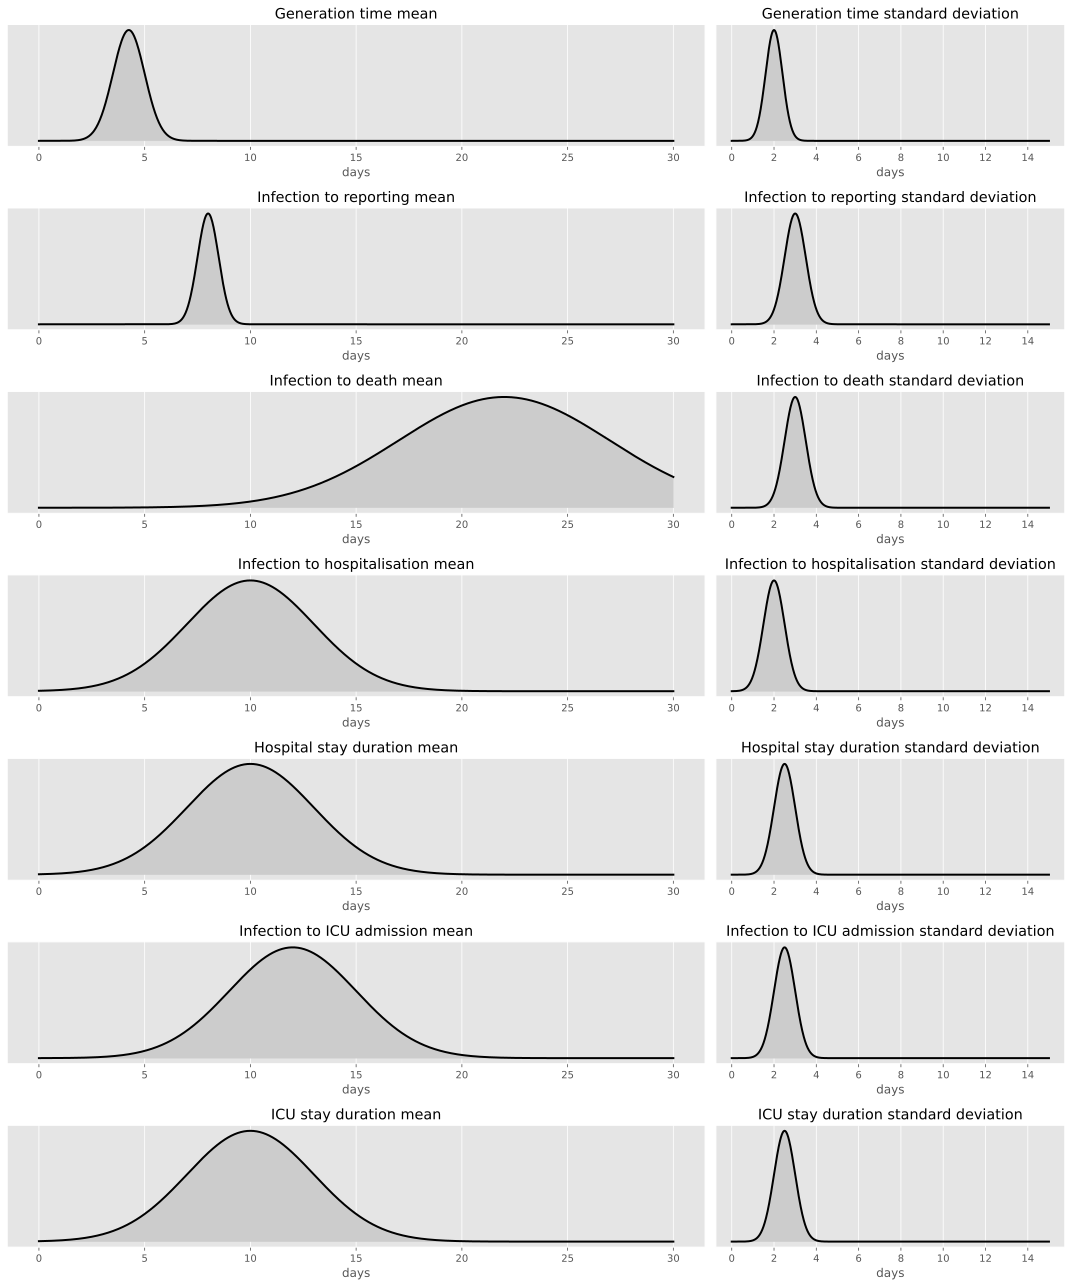

In [4]:
#| fig-cap: Duration-related parameter prior distributions.
plot_duration_params(duration_params)

In [5]:
betas_df = get_table_df_from_priors_dict(loaded_priors["beta"])
caption = "\n: Parameters and supporting evidence to beta-distributed priors. "
Markdown(betas_df.to_markdown() + caption + col_widths)

|                                      |   Mean |    SD | Evidence                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     |
|:-------------------------------------|-------:|------:|:-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Case detection proportion            |  0.4   | 0.1   | An analysis from France in early to mid-2020 of the proportion of cases detected estimated that case ascertainment increased from 7% to 38% (95% confidence interval 35 to 44%) over time.[@pullano2020] A study of multiple countries found that case detection was highly dependent on the country considered, but reached 20 to 60% in several European countries by the middle of 2020.[@russell2020] Estimates from the UK Health Security Agency placed the proportion of cases detected over time at around 30 to 60% from the latter half of 2020.[@ukhsa2024] These estimates are consistent with our previous estimate that one in two to one in six cases were detected from the early stages of Australia's Omicron outbreak.[@trauer2025] An analysis from Africa estimated generally lower case ascertainment proportions, which also varied significantly by country.[@impouma2021] \newline\newline Given the difficulty in determining an appropriate prior for this parameter and the likelihood that the quantity is highly setting-dependent, we selected a broad prior distribution for this parameter. |
| Cross immunity                       |  0.5   | 0.1   | A pre-print describing a large dataset from the USA in 2020 found an 87% lower rate of reinfection compared to primary infection over a median five months of follow-up.[@reynolds2022] \newline\newline A systematic review and meta-analysis found that protection against re-infection declined with time and varied with the variant considered, but was estimated at 78.6% after 40 weeks from infection (95% uncertainty interval 49.8 to 93.6%).[@covidforecasting2023] Another systematic review and meta-analysis of the same topic found 65% protection (credible interval 53 to 74%) overall, with the past infecting variant and time from infection appearing to modify the extent of protection.[@hu2024] A systematic review and meta-regression of reinfections with Omicron variants found that protection from previous infections waned to lower levels (25%) by 12 months from infection.[@bobrovitz2023]                                                                                                                                                                                                |
| Infection hospitalisation proportion |  0.03  | 0.006 | This quantity was estimated to be 3.39% (credible interval 2.79 to 3.97%) from officially reported data in England prior to the marked declines that occurred as population-wide vaccination was rolled out.[@ward2024] An analysis from Indiana, USA estimated a value of 2.1% overall (credible interval 1.6 to 3.0%), with substantial variation by demographic factors, particularly age.[@menachemi2021] A study from the USA estimated that one in three adults aged 70 years and above who were infected were hospitalised, while one in 21.6 infections in those aged 18 to 49 years resulted in hospitalisation.[@deng2025]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         |
| Infection fatality proportion        |  0.008 | 0.001 | An analysis that integrated serosurveillance with age-specific death rates from 45 countries estimated an infection fatality rate of 0.79% (credible interval 0.68 to 0.92%) for the reference population distribution of France.[@odriscoll2021] Other groups have found similar estimates using a combination of modelling and serosurvey results, including an overall IFR estimated at 0.49 to 2.53%.[@brazeau2022] The analysis from England of the hospitalisation risk estimated a peak infection fatality risk of 0.97% in January 2021, which fell to 0.06% by April 2022.[@ward2024] \newline\newline We selected a prior distribution with a central estimate of 0.8%. Our prior estimate is relatively broadly distributed and so should be applicable to a range of higher income settings.                                                                                                                                                                                                                                                                                                                     |
| ICU admission proportion             |  0.01  | 0.001 | The analysis from Indiana cited above found an infection ICU admission risk of 0.51% (credible interval 0.38% to 0.70%).[@ menachemi2021] An analysis from Chile found a risk of ICU admission given infection of 0.33, 1.18, 3.59 and 7.18% for the age groups under 40, 40 to 49, 50 to 59 and 60 to 69 respectively.[@saure2023] A systematic review and meta-analysis from early in the pandemic period found that 32% of hospital admissions resulted in ICU admission.[@abate2020] \newline\newline We therefore chose a central estimate for this parameter of 1%.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    |
: Parameters and supporting evidence to beta-distributed priors. {tbl-colwidths="[12, 7, 7, 74]"}

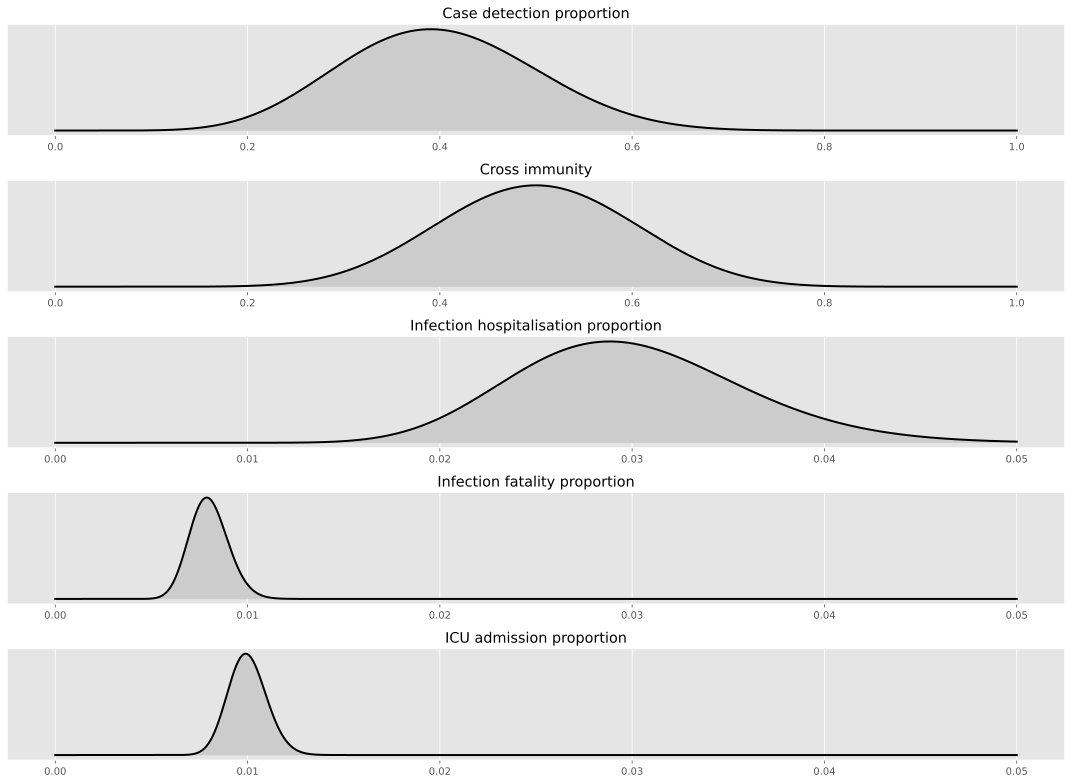

In [6]:
#| fig-cap: Proportion parameter prior distributions.
plot_beta_priors(loaded_priors["beta"])

In [14]:
fixed_params = loaded_priors["fixed"]
params_df = pd.DataFrame.from_dict(fixed_params).T
params_df = params_df.set_index("param_name")
params_df.columns = params_df.columns.str.capitalize()
params_df.index.name = None

In [15]:
Markdown(params_df.to_markdown() + "\n" + caption + '{tbl-colwidths="[12, 7, 81]"}')

|                                                |   Value | Evidence                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                |
|:-----------------------------------------------|--------:|:----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Vaccination protection against hospitalisation |    0.5  | The first estimate of the efficacy of BNT162b2 mRNA vaccine that was widely used in Australia, found a total efficacy of 95% protection against COVID-19.[@polack2020] \newline\newline However, protection against infection will be captured by scaling the modelled transmission parameters, including the variable process. As such, the evidence needed for this quantity is the real-world reduction in the risk of hospitalisation and death given infection. \newline\newline Estimates of the real-world protection of vaccination against SARS-CoV-2 infections found 85% protection (95% confidence interval 81 to 89%) against infection, but higher protection against severe outcomes, including hospitalisation (93%), ICU admission (98%) and death (95%).[@liu2021] \newline\newline As such, we estimated the reduction in hospitalisation given infection to be 50%. |
| Vaccination protection against death           |    0.67 | Using the same evidence as for the protection against hospitalisation, we estimated this parameter at 67%.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              |

: Parameters and supporting evidence to beta-distributed priors. {tbl-colwidths="[12, 7, 81]"}